# Environment

In [1]:
library(dplyr)
library(DBI)
library(RSQLite)
library(sf)
library(spdep)
library(sp)
library(tidyverse)
library(grf)
library(spatialRF)
library(arrow)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'RSQLite' was built under R version 4.5.2"
Linking to GEOS 3.13.1, GDAL 3.11.0, PROJ 9.6.0; sf_use_s2() is TRUE

Loading required package: spData

To access larger datasets in this package, install the spDataLarge
package with: `install.packages('spDataLarge',
repos='https://nowosad.github.io/drat/', type='source')`

Warning message:
"package 'tidyverse' was built under R version 4.5.2"
Warning message:
"package 'readr' was built under R version 4.5.2"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.6
✔ ggplot2   4.0.0     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts

# Loading data

In [2]:
repo_path <- dirname(file.path(getwd()))
list_of_columns <- c(
  'gdf_rho_0_775', 'gdf_rho_0_725', 'gdf_rho_0_674', 'gdf_rho_0_624', 'gdf_rho_0_574', 'gdf_rho_0_524', 'gdf_rho_0_474', 'gdf_rho_0_424', 'gdf_rho_0_374', 'gdf_rho_0_324', 'gdf_rho_0_274', 'gdf_rho_0_224', 'gdf_rho_0_174', 'gdf_rho_0_124', 'gdf_rho_0_074', 'gdf_rho_0_024'
)

con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

dict_geom_sf <- setNames(
  lapply(list_of_columns, function(layer) {

    geom_df <- dbReadTable(con, layer)

    geom <- st_as_sfc(geom_df$GEOMETRY, EWKB = TRUE)

    sf_obj <- st_sf(
      geom_df[, setdiff(names(geom_df), c("geometry", "GEOMETRY", "ogc_fid"))],
      geometry = geom
    )

    st_crs(sf_obj) <- 3857
    geom_df2 <- geom_df[, !(names(geom_df) %in% c("GEOMETRY", "ogc_fid"))]

    return(list(
      sf = sf_obj,
      df = geom_df2
    ))
  }),
  list_of_columns
)

dbDisconnect(con)

# Distance matrix

In [4]:
centroids <- sf::st_centroid(dict_geom_sf$gdf_rho_0_725$sf)

distance_matrix <- units::drop_units(
  as.matrix(sf::st_distance(centroids))
)

# Preparing and saving spatial predictors

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5305407
  - R squared (cor(obs, pred)^2):     0.9458499
  - Pseudo R squared (cor(obs, pred)):0.9725482
  - RMSE (oob):                       0.9184254
  - RMSE:                             0.397
  - Normalized RMSE:                  0.2251437

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.19 │  -

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            16
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.514154
  - R squared (cor(obs, pred)^2):     0.9500002
  - Pseudo R squared (cor(obs, pred)):0.9746795
  - RMSE (oob):                       0.9997142
  - RMSE:                             0.4228
  - Normalized RMSE:                  0.2289371

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.57 │  -

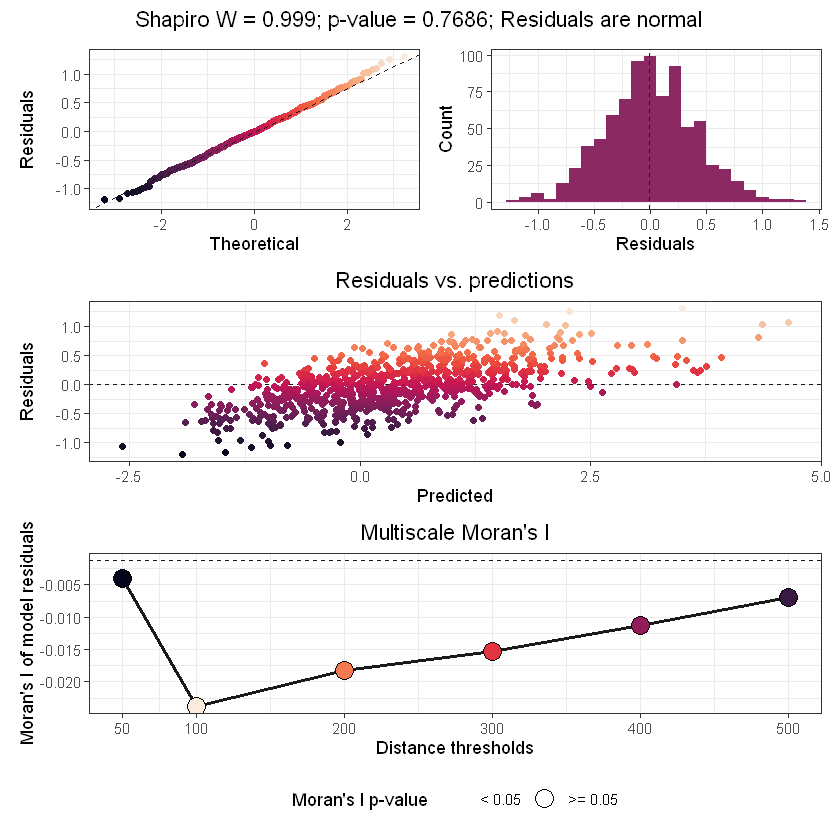

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.529157
  - R squared (cor(obs, pred)^2):     0.9439373
  - Pseudo R squared (cor(obs, pred)):0.9715643
  - RMSE (oob):                       0.9330942
  - RMSE:                             0.4007
  - Normalized RMSE:                  0.2137655

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.49 │  -

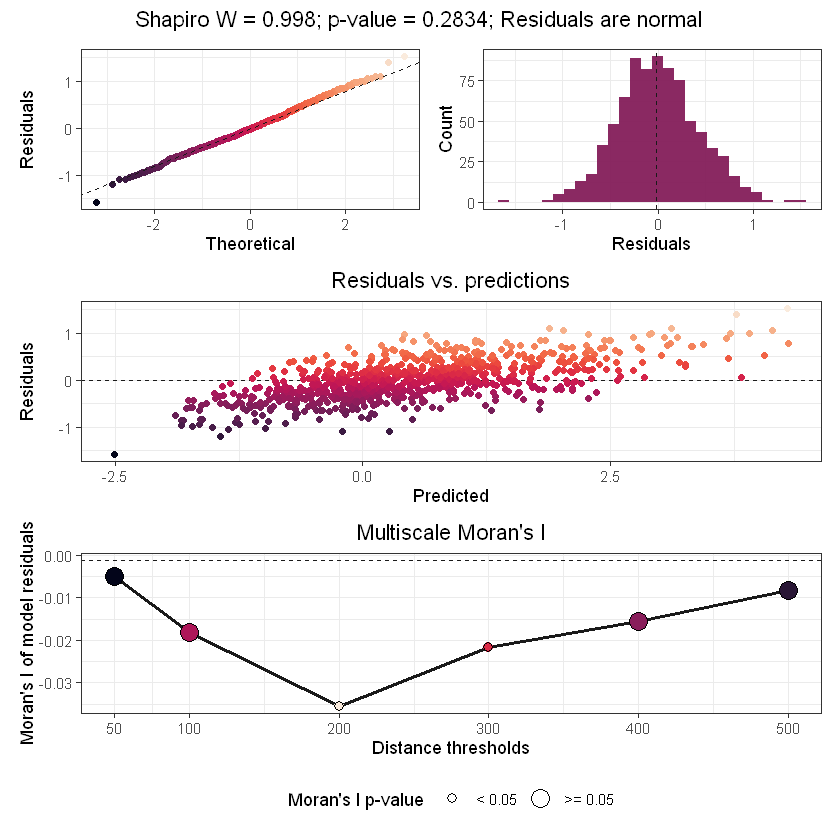

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5514212
  - R squared (cor(obs, pred)^2):     0.9478956
  - Pseudo R squared (cor(obs, pred)):0.9735993
  - RMSE (oob):                       0.901881
  - RMSE:                             0.3887
  - Normalized RMSE:                  0.2271307

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.31 │  -

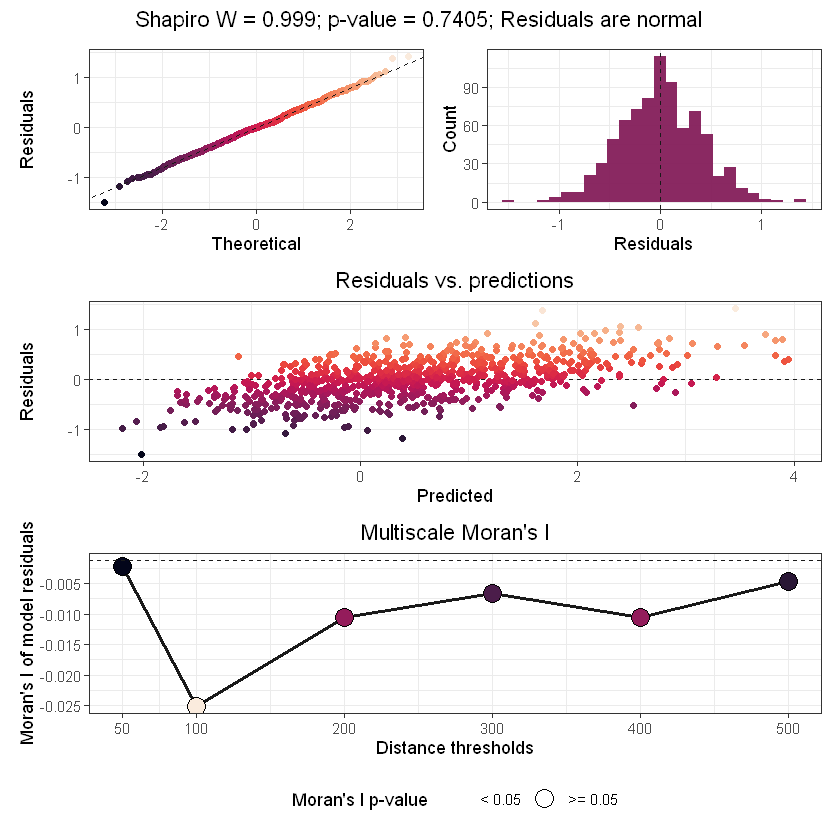

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5179843
  - R squared (cor(obs, pred)^2):     0.9432982
  - Pseudo R squared (cor(obs, pred)):0.9712354
  - RMSE (oob):                       0.9360905
  - RMSE:                             0.4024
  - Normalized RMSE:                  0.2338027

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.52 │  

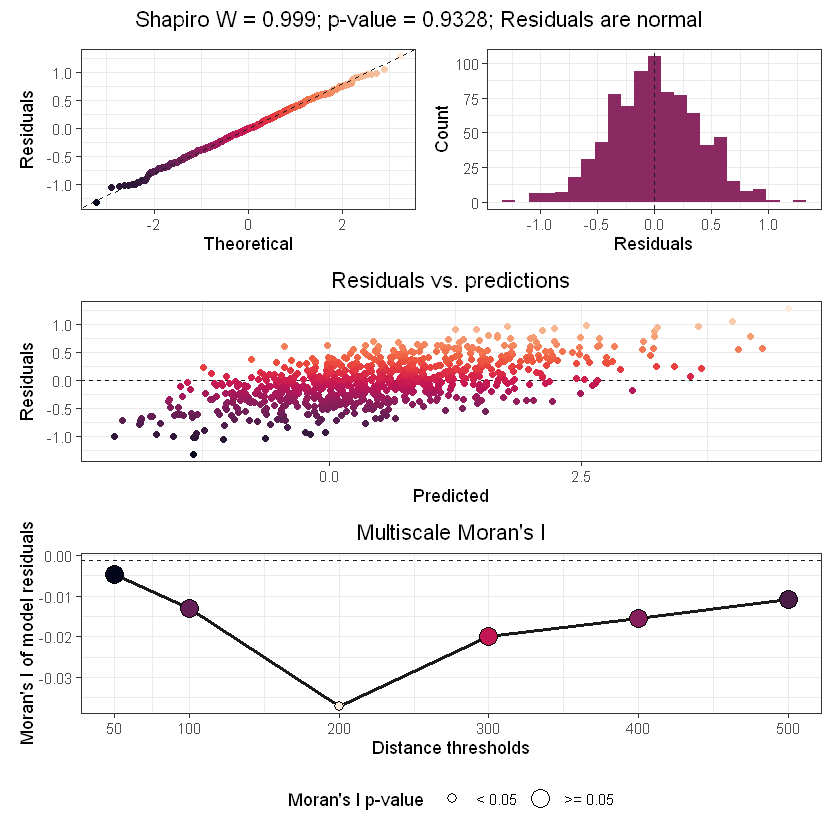

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4938094
  - R squared (cor(obs, pred)^2):     0.9439267
  - Pseudo R squared (cor(obs, pred)):0.9715589
  - RMSE (oob):                       0.9738092
  - RMSE:                             0.4202
  - Normalized RMSE:                  0.2421546

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.47 │  

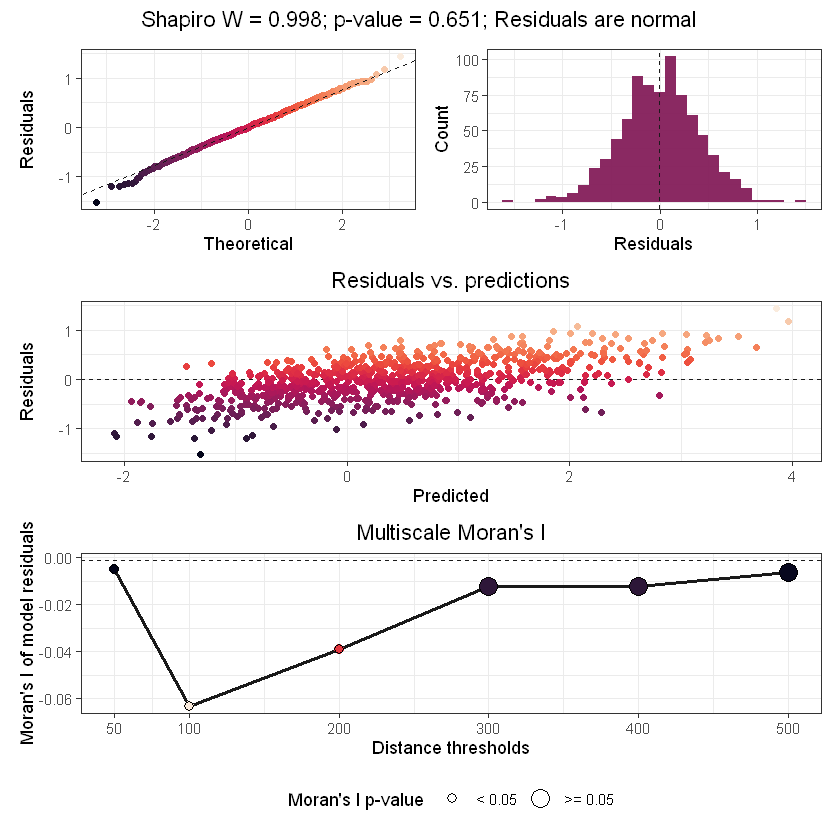

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5510945
  - R squared (cor(obs, pred)^2):     0.9460911
  - Pseudo R squared (cor(obs, pred)):0.9726722
  - RMSE (oob):                       0.9320183
  - RMSE:                             0.4028
  - Normalized RMSE:                  0.2387207

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.44 │  

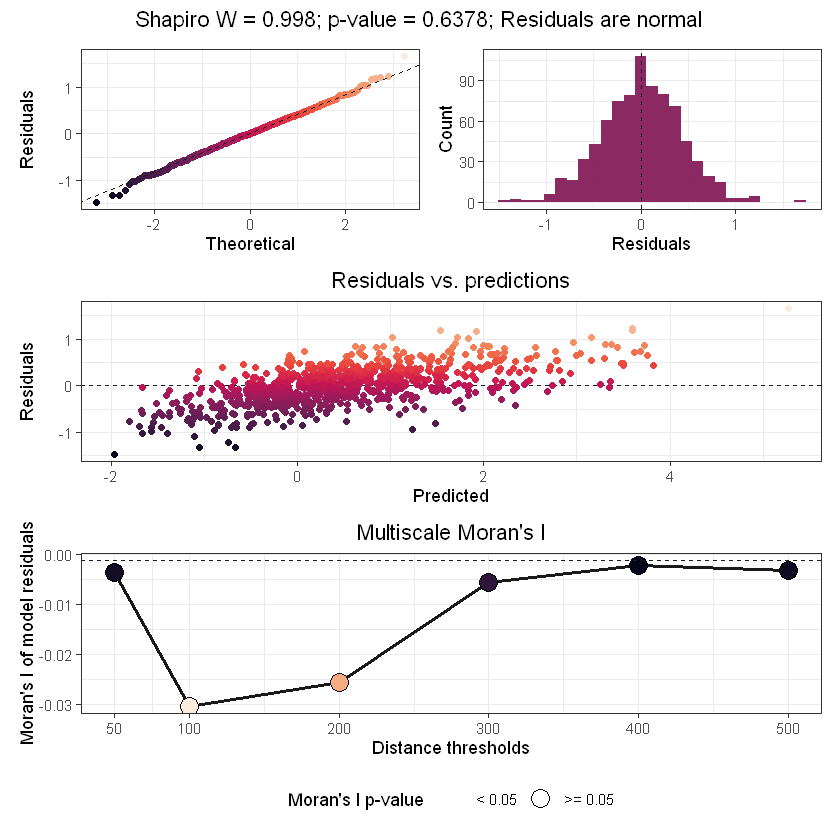

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            16
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5838117
  - R squared (cor(obs, pred)^2):     0.9563715
  - Pseudo R squared (cor(obs, pred)):0.9779425
  - RMSE (oob):                       0.9272214
  - RMSE:                             0.3919
  - Normalized RMSE:                  0.2321931

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.18 │  

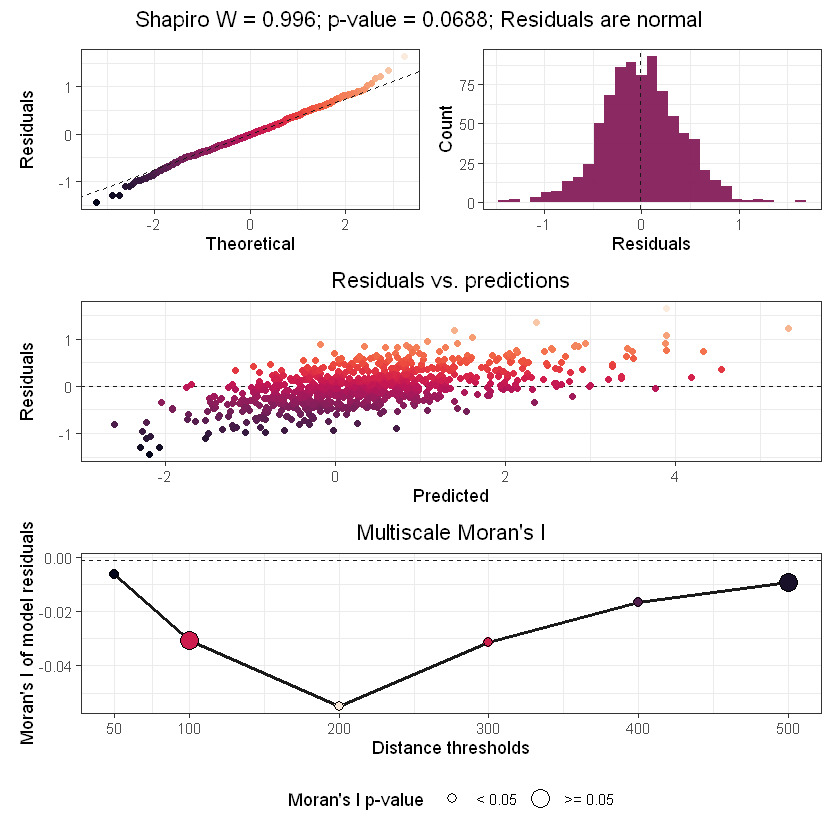

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4926685
  - R squared (cor(obs, pred)^2):     0.9409992
  - Pseudo R squared (cor(obs, pred)):0.9700511
  - RMSE (oob):                       0.9428501
  - RMSE:                             0.4068
  - Normalized RMSE:                  0.2392614

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.52 │  

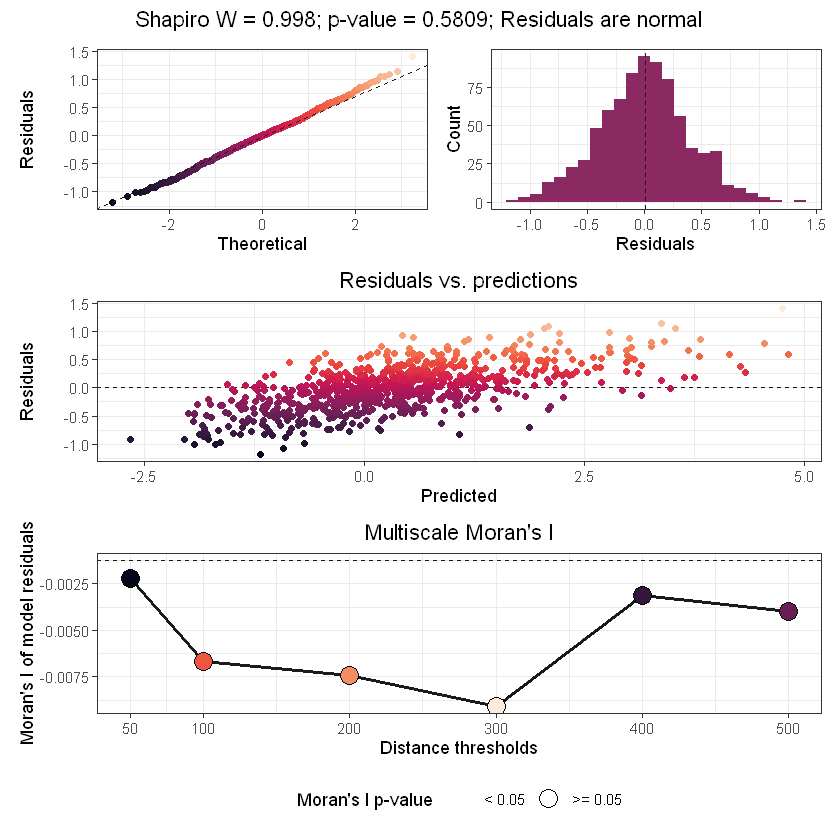

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5194262
  - R squared (cor(obs, pred)^2):     0.9442028
  - Pseudo R squared (cor(obs, pred)):0.971701
  - RMSE (oob):                       0.9396904
  - RMSE:                             0.4088
  - Normalized RMSE:                  0.2324407

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.35 │  -0

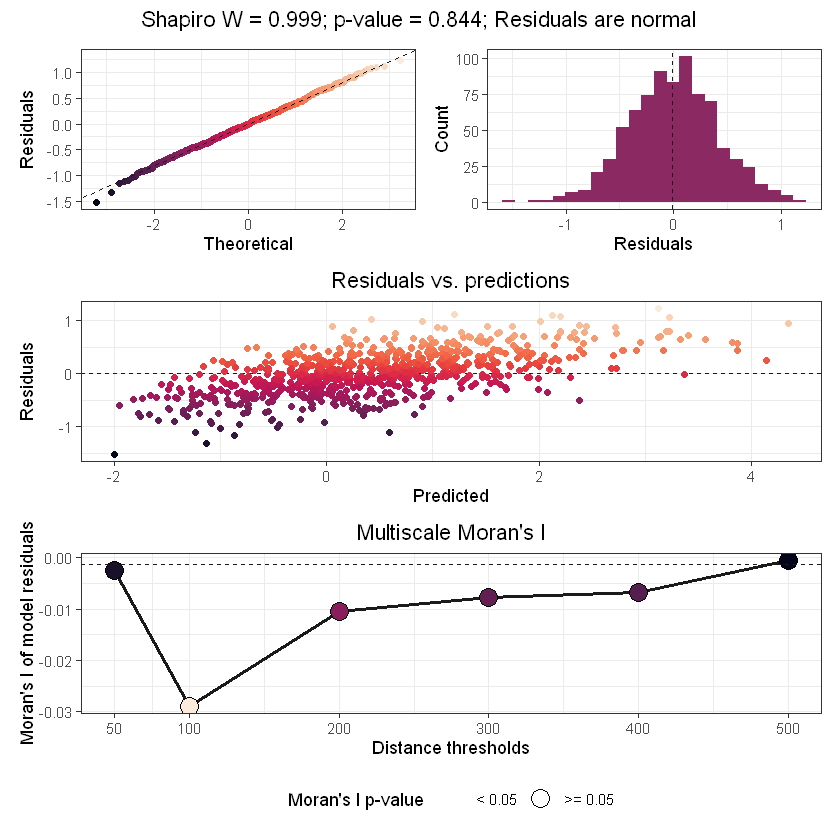

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5204845
  - R squared (cor(obs, pred)^2):     0.9431199
  - Pseudo R squared (cor(obs, pred)):0.9711436
  - RMSE (oob):                       0.9260565
  - RMSE:                             0.4006
  - Normalized RMSE:                  0.2345283

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.56 │  

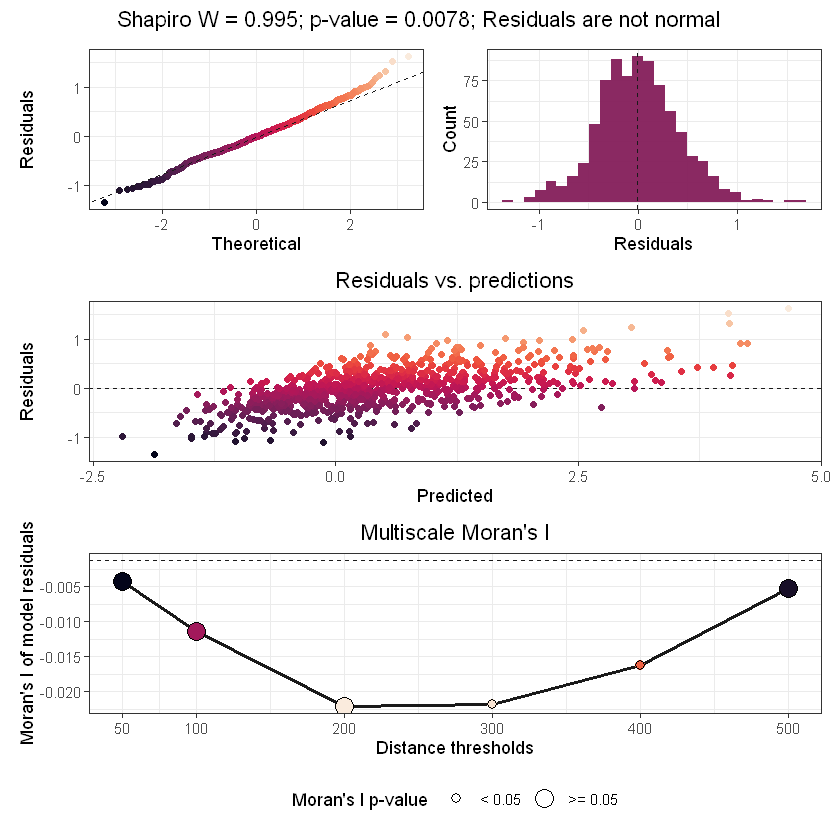

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5415914
  - R squared (cor(obs, pred)^2):     0.944067
  - Pseudo R squared (cor(obs, pred)):0.9716311
  - RMSE (oob):                       0.9389698
  - RMSE:                             0.4053
  - Normalized RMSE:                  0.2195696

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.37 │  -

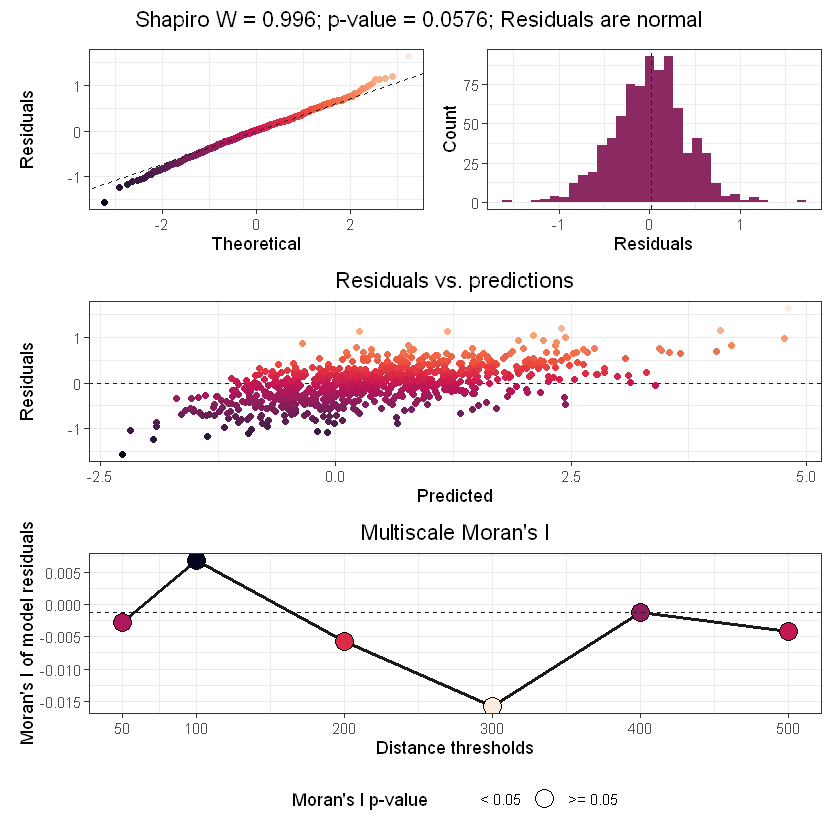

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4706746
  - R squared (cor(obs, pred)^2):     0.939742
  - Pseudo R squared (cor(obs, pred)):0.9694029
  - RMSE (oob):                       0.951698
  - RMSE:                             0.4132
  - Normalized RMSE:                  0.2362357

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.33 │  -0

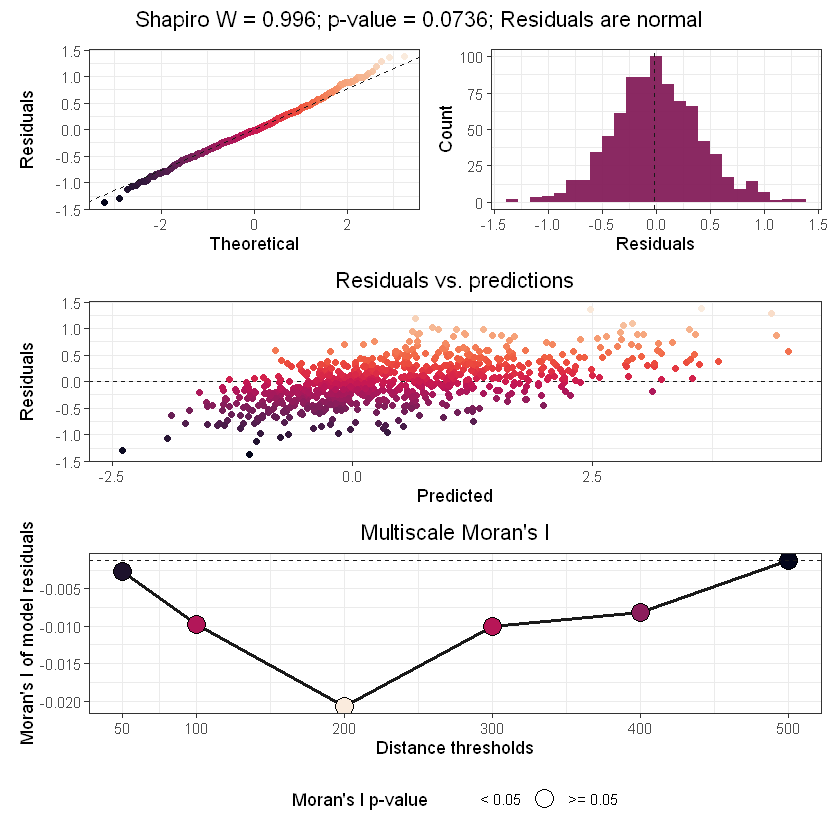

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4657956
  - R squared (cor(obs, pred)^2):     0.9388634
  - Pseudo R squared (cor(obs, pred)):0.9689497
  - RMSE (oob):                       0.953976
  - RMSE:                             0.4115
  - Normalized RMSE:                  0.233097

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.55 │  -0

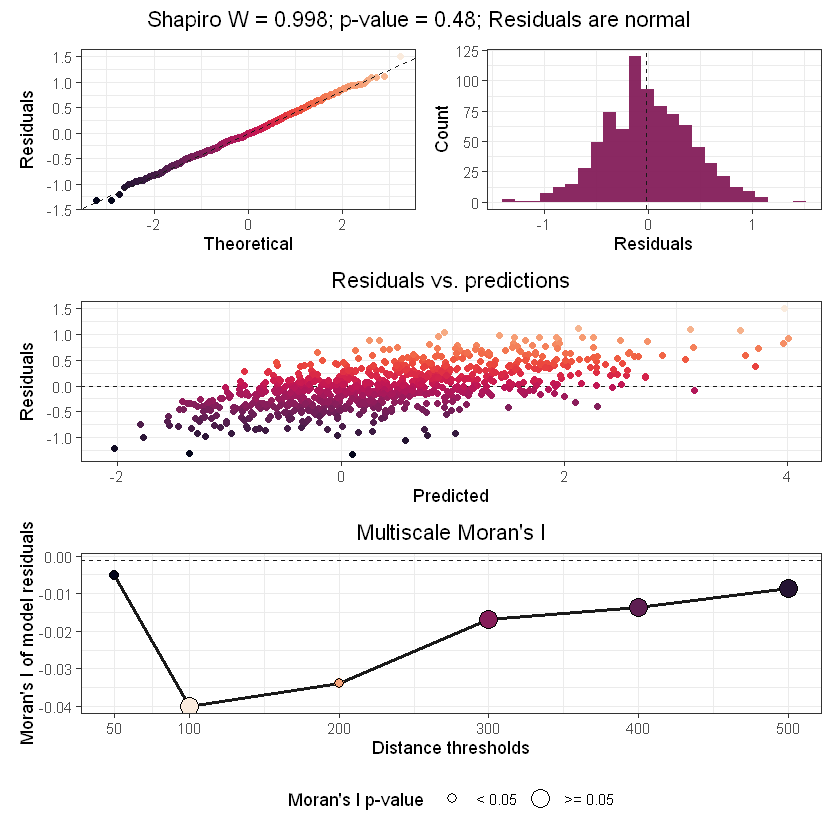

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            11
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.4798284
  - R squared (cor(obs, pred)^2):     0.9394584
  - Pseudo R squared (cor(obs, pred)):0.9692566
  - RMSE (oob):                       0.9622817
  - RMSE:                             0.4184
  - Normalized RMSE:                  0.2382365

Model residuals 
  - Stats: 
               ┌───────┬────────┬────────┬──────┬────────┬──────┐
               │ Min.  │ 1st Q. │ Median │ Mean │ 3rd Q. │ Max. │
               ├───────┼────────┼────────┼──────┼────────┼──────┤
               │ -1.36 │  

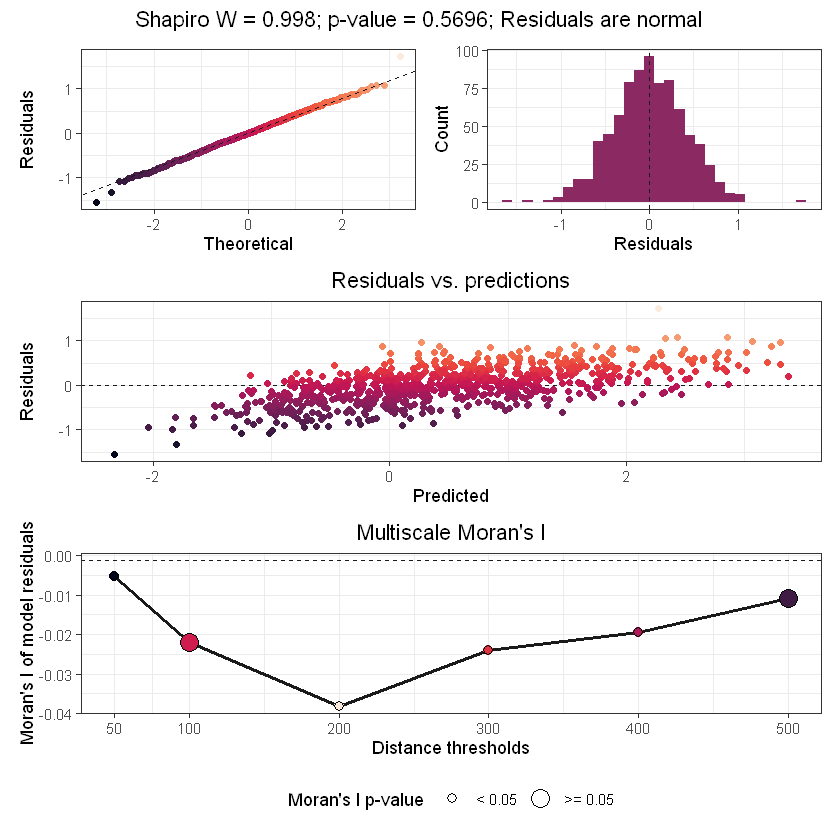

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y_dep_var

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            10
  - Mtry:                            3
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5203492
  - R squared (cor(obs, pred)^2):     0.9438785
  - Pseudo R squared (cor(obs, pred)):0.9715341
  - RMSE (oob):                       0.919303
  - RMSE:                             0.3971
  - Normalized RMSE:                  0.2401418

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.18 │  -0

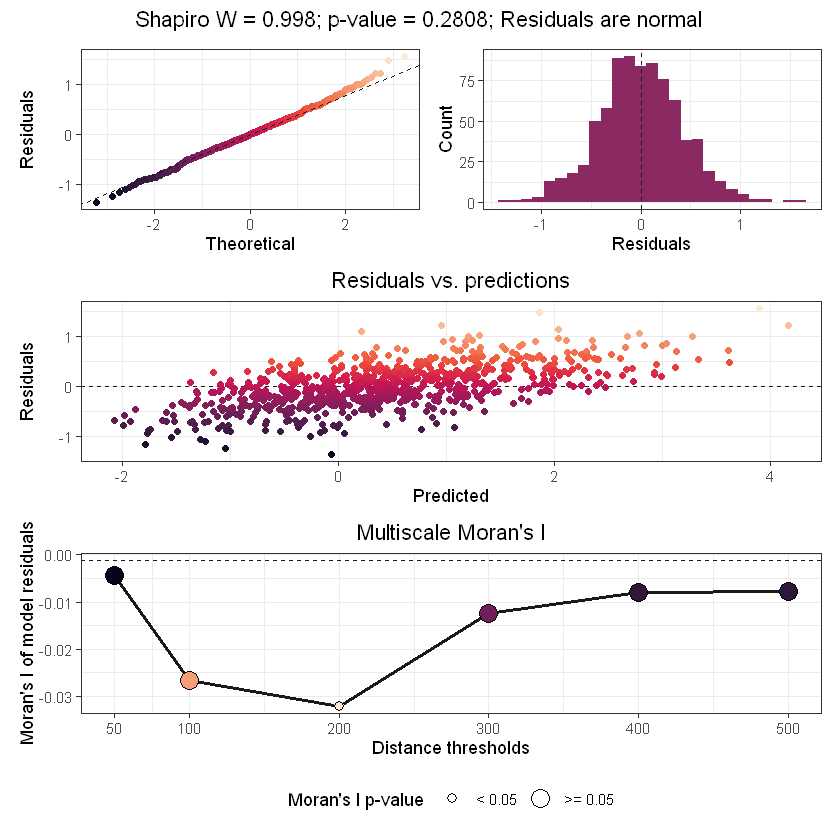

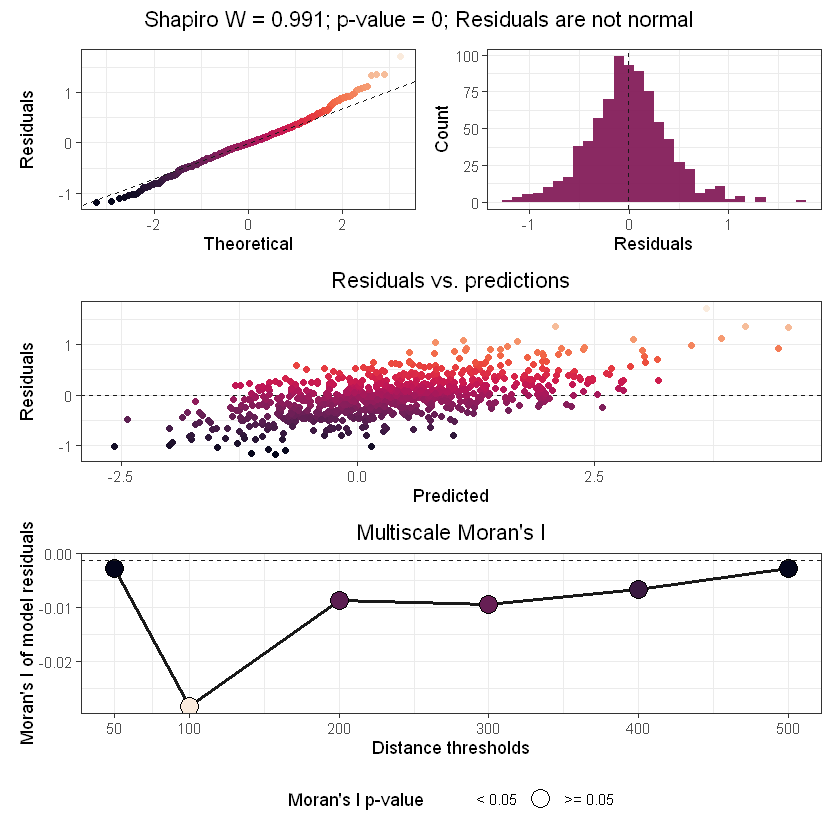

In [7]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

for (layer in list_of_columns) {

  df1 <- dict_geom_sf[[layer]]$df

  model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "y_dep_var",
    predictor.variable.names = c('c1', 'c2'
                  #'t', 'odr_1','odr_2','odr_3','odr_4','odr_5'
                  ),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

  spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

  df3 <- cbind(df1, spatial_predictors_df)

  dbWriteTable(
    con,
    paste0(layer, "_sp"),
    df3,
    overwrite = TRUE
  )
}

dbDisconnect(con)

The model residuals are spatially correlated, fitting a spatial model.

Using Moran's Eigenvector Maps as spatial predictors.

Ranking spatial predictors by their Moran's I.

Sequential selection of spatial predictors.

Details about the spatial predictors stored in model$spatial.



Model type
  - Fitted with:                     rf_spatial()
  - rf_spatial() method:             mem.moran.sequential
  - Response variable:               y

Random forest parameters
  - Type:                            Regression
  - Number of trees:                 500
  - Sample size:                     800
  - Number of predictors:            17
  - Mtry:                            4
  - Minimum node size:               5


Model performance 
  - R squared (oob):                  0.5382676
  - R squared (cor(obs, pred)^2):     0.9420326
  - Pseudo R squared (cor(obs, pred)):0.9705836
  - RMSE (oob):                       0.9668107
  - RMSE:                             0.4281
  - Normalized RMSE:                  0.2332028

Model residuals 
  - Stats: 
              ┌───────┬────────┬────────┬───────┬────────┬──────┐
              │ Min.  │ 1st Q. │ Median │ Mean  │ 3rd Q. │ Max. │
              ├───────┼────────┼────────┼───────┼────────┼──────┤
              │ -1.49 │  -0.29 │  

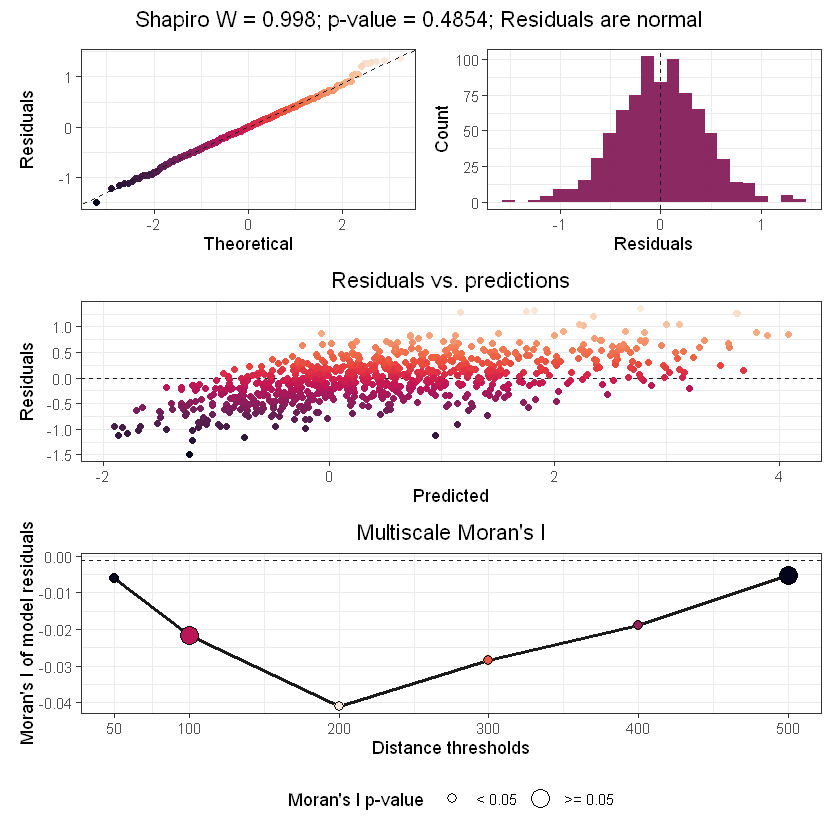

In [13]:
df1 <- dict_geom_sf[['gdf_rho_0_75']]$df

model <- spatialRF::rf_spatial(
    data = df1,
    dependent.variable.name = "y",
    predictor.variable.names = c('c1', 'c2', 't', 'odr_1','odr_2','odr_3','odr_4','odr_5'
                  ),
    distance.matrix = distance_matrix,
    distance.thresholds = c(50, 100, 200, 300, 400, 500)
  )

spatial_predictors_df <- spatialRF::get_spatial_predictors(model)

df3 <- cbind(df1, spatial_predictors_df)


In [15]:
con <- dbConnect(
  RSQLite::SQLite(),
  paste0(repo_path, "/03_simulated_data/simulated_data.sqlite")
)

dbWriteTable(
    con,
    paste0("gdf_rho_0_75_sp_t_dr5"),
    df3,
    overwrite = TRUE
  )


dbDisconnect(con)